In [ ]:
!pip install torchsummary -q
!pip install timm -q
!pip install torchinfo -q
!pip install tqdm -q
!pip install transformers
!pip install huggingface-hub -q

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms
import torch.nn as nn
import torchvision.models as models
from torchsummary import summary

from collections import Counter


from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split



%matplotlib inline

# Set default aesthetics for seaborn
sns.set(style="whitegrid")

# Data Loading and Pre-processing

In [ ]:
#!/bin/bash
!curl -L -o /content/Dataset   https://www.kaggle.com/api/v1/datasets/download/ashery/chexpert

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 10.7G  100 10.7G    0     0  15.4M      0  0:11:50  0:11:50 --:--:-- 15.0M


In [ ]:
!unzip -q "/content/Dataset" -d "/content/CheXpert-v1.0-small"

In [ ]:
chexpert_root = "/content/CheXpert-v1.0-small"

train_csv = os.path.join(chexpert_root, "train.csv")
valid_csv = os.path.join(chexpert_root, "valid.csv")

train_val_df = pd.read_csv(train_csv)
test_df = pd.read_csv(valid_csv)

print("Train size:", len(train_val_df))
print("Valid size:", len(test_df))

Train size: 223414
Valid size: 234


In [ ]:
train_val_df = train_val_df[train_val_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)
test_df = test_df[test_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)

In [ ]:
chexpert_labels = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Enlarged Cardiomediastinum",
    "Lung Opacity",
    "Lung Lesion",
    "Pneumonia",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices",
    "No Finding"
]

In [ ]:
train_val_df[chexpert_labels] = train_val_df[chexpert_labels].fillna(0)
test_df[chexpert_labels] = test_df[chexpert_labels].fillna(0)

train_val_df[chexpert_labels] = train_val_df[chexpert_labels].replace(-1, 0)
test_df[chexpert_labels] = test_df[chexpert_labels].replace(-1, 0)

In [ ]:
train_val_df["patient_id"] = train_val_df["Path"].apply(
    lambda x: x.split("/")[2]
)

test_df["patient_id"] = test_df["Path"].apply(
    lambda x: x.split("/")[2]
)

In [ ]:
print(train_val_df["patient_id"].nunique())
print(test_df["patient_id"].nunique())

64534
200


In [ ]:
train_val_df["full_image_path"] = train_val_df["Path"].apply(
    lambda x: os.path.join("/content", x)
)

test_df["full_image_path"] = test_df["Path"].apply(
    lambda x: os.path.join("/content", x)
)

In [ ]:
train_val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191027 entries, 0 to 191026
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Path                        191027 non-null  object 
 1   Sex                         191027 non-null  object 
 2   Age                         191027 non-null  int64  
 3   Frontal/Lateral             191027 non-null  object 
 4   AP/PA                       191027 non-null  object 
 5   No Finding                  191027 non-null  float64
 6   Enlarged Cardiomediastinum  191027 non-null  float64
 7   Cardiomegaly                191027 non-null  float64
 8   Lung Opacity                191027 non-null  float64
 9   Lung Lesion                 191027 non-null  float64
 10  Edema                       191027 non-null  float64
 11  Consolidation               191027 non-null  float64
 12  Pneumonia                   191027 non-null  float64
 13  Atelectasis   

In [ ]:

train_val_df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,patient_id,full_image_path
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,patient00001,/content/CheXpert-v1.0-small/train/patient0000...
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,patient00002,/content/CheXpert-v1.0-small/train/patient0000...
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,patient00002,/content/CheXpert-v1.0-small/train/patient0000...
3,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,patient00003,/content/CheXpert-v1.0-small/train/patient0000...
4,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,patient00004,/content/CheXpert-v1.0-small/train/patient0000...


In [ ]:
from sklearn.model_selection import train_test_split

unique_patients = train_val_df["patient_id"].unique()

train_patients, val_patients = train_test_split(
    unique_patients,
    test_size=0.2,
    random_state=42
)

In [ ]:
train_df = train_val_df[train_val_df["patient_id"].isin(train_patients)].reset_index(drop=True)

val_df = train_val_df[train_val_df["patient_id"].isin(val_patients)].reset_index(drop=True)

In [ ]:

train_count = len(train_df)
val_count = len(val_df)
test_count = len(test_df)

print("\n" + "="*60)
print("FINAL DATASET SPLIT STATISTICS")
print("="*60)
print(f"Training images:             {train_count}")
print(f"Validation images:           {val_count}")
print(f"Test images:                 {test_count}")
print(f"Sum (Train+Val+Test):        {train_count+val_count+test_count:,}")
print("="*60)

print("\nUnique patients:")
print(f"  Training:   {train_df['patient_id'].nunique()} unique patients")
print(f"  Validation: {val_df['patient_id'].nunique()} unique patients")
print(f"  Test:       {test_df['patient_id'].nunique()} unique patients")
print("="*60)


FINAL DATASET SPLIT STATISTICS
Training images:             152594
Validation images:           38433
Test images:                 202
Sum (Train+Val+Test):        191,229

Unique patients:
  Training:   51627 unique patients
  Validation: 12907 unique patients
  Test:       200 unique patients


In [ ]:
class CheXpertDataset(Dataset):
    def __init__(self, dataframe, label_cols, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_cols = label_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img_path = row["full_image_path"]  # make sure this column exists
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Extract labels
        labels = row[self.label_cols].values.astype(np.float32)

        # U-Zeros strategy for uncertain labels
        labels = np.where(labels == -1, 0, labels)

        labels = torch.tensor(labels, dtype=torch.float32)

        return image, labels

In [ ]:
from torchvision import transforms

# Training transform
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # Convert 1-channel to 3-channel
    transforms.Resize((224, 224)),                 # Resize to ViT/CNN input size (Dataset is already resized to 224x224)
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.01, contrast=0.01),# Augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean/std
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transform
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
#preporcessing data
train_dataset = CheXpertDataset(train_df,label_cols=chexpert_labels,transform=train_transform)
val_dataset = CheXpertDataset(val_df,label_cols=chexpert_labels, transform=val_transform)
test_dataset = CheXpertDataset(test_df,label_cols=chexpert_labels, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

#Model Building

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class CNNBranch(nn.Module):
    def __init__(self, out_dim=768, pretrained=True, freeze=False):
        super(CNNBranch, self).__init__()

        #Load DenseNet-121
        densenet = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        )

        dense_feats = list(densenet.features.children())

        # Extract up to denseblock3 (index 8)
        self.features = nn.Sequential(
            *dense_feats[:9]
            )   # includes index 8

        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

        # After denseblock3:
        # Output shape: (B, 1024, 14, 14)
        in_channels = 1024

        # Project to ViT embedding dimension
        self.proj = nn.Conv2d(in_channels, out_dim, kernel_size=1, bias=False)
        self.ln = nn.LayerNorm(out_dim)

    def forward(self, x):
        # CNN feature map: (B, 1024, 14, 14)
        feat = self.features(x)

        # Project to 768 channels
        feat = self.proj(feat)  # (B, 768, 14, 14)

        # Flatten spatial tokens 14×14 = 196 tokens
        tokens = feat.flatten(2).transpose(1, 2)  # (B, 196, 768)

        # Normalize tokens
        return self.ln(tokens)


In [ ]:
!pip install open_clip_torch transformers pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


from open_clip import create_model_from_pretrained
class BiomedCLIPViTBranch(nn.Module):
    """
    BiomedCLIP ViT branch
    """
    def __init__(self, target_dim=768, freeze=True, dropout=0.1):
        super().__init__()

        print("\n" + "="*70)
        print("Loading BiomedCLIP ViT Branch (Fixed with Projection)")
        print("="*70)


        # Load BiomedCLIP model
        print("\nLoading BiomedCLIP from HuggingFace...")
        self.model, self.preprocess = create_model_from_pretrained(
            'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
        )
        self.model_loaded = "BiomedCLIP"
        print("BiomedCLIP loaded successfully!")

        # Extract vision encoder
        self.vision_model = self.model.visual
        print("Vision encoder extracted")


        if hasattr(self.vision_model, 'output_dim'):
            self.actual_dim = self.vision_model.output_dim
            print(f"    BiomedCLIP output_dim: {self.actual_dim}")
        elif hasattr(self.vision_model, 'embed_dim'):
            self.actual_dim = self.vision_model.embed_dim
            print(f"    BiomedCLIP embed_dim: {self.actual_dim}")
        else:
            # Infer from model structure
            self.actual_dim = 512  # BiomedCLIP default
            print(f"    BiomedCLIP inferred dim: {self.actual_dim}")



        print(f"\nSetting up dimension projection...")
        print(f"    Input dimension: {self.actual_dim}")
        print(f"    Target dimension: {target_dim}")

        if self.actual_dim != target_dim:
            # Create projection layer
            self.proj = nn.Linear(self.actual_dim, target_dim)
            print(f"Projection layer created ({self.actual_dim} -> {target_dim})")
            self.needs_projection = True
        else:
            # No projection needed
            self.proj = nn.Identity()
            print(f"No projection needed (dimensions match)")
            self.needs_projection = False

        self.embed_dim = target_dim  #Output dimension is always target_dim


        if freeze:
            for p in self.vision_model.parameters():
                p.requires_grad = False
            print(f"\n{self.model_loaded} backbone frozen")

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        print(f"\n{'='*70}")
        print(f"Configuration:")
        print(f"  Model: {self.model_loaded}")
        print(f"  Input Dim: {self.actual_dim}")
        print(f"  Output Dim: {self.embed_dim}")
        print(f"  Projection: {self.needs_projection}")
        print(f"  Frozen: {freeze}")
        print(f"  Dropout: {dropout}")
        print(f"  CLIP Model Type: {type(self.vision_model)}")
        print(f"  CLIP Model: {self.vision_model}")
        print(f"{'='*70}\n")

    def forward(self, x):
            """
            x: (B, 3, H, W)
            returns: (B, embed_dim)  - projected features ready for fusion.
            """
            #extracting vison model of BiomedCLIP
            vision = self.vision_model

            # Vision models accept the image tensor and return image features.
            # Handling a few common possibilities to be robust.
            with torch.no_grad() if not any(p.requires_grad for p in vision.parameters()) else torch.enable_grad():
                # vision(x) returns a (B, D) feature tensor
                try:
                    image_features = vision(x)   # (B,D)
                except Exception:
                    # fallback- call trunk explicitly if it exists
                    if hasattr(vision, "trunk"):
                        image_features = vision.trunk(x)  # trunk typically returns (B, D) or (B, N, D)
                    else:
                        # trying visual.forward
                        image_features = vision.forward(x)


            if isinstance(image_features, (tuple, list)):
                image_features = image_features[0]

            # If (B, N, D) (sequence tokens), pool to get (B, D)
            if image_features.ndim == 3:
                # extracting the [cls] token
                image_features = image_features[:, 0, :]

            # Project to target dim if needed
            image_features = self.proj(image_features)   # (B, target_dim)
            image_features = self.dropout(image_features)

            return image_features  # (B, target_dim)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DynamicFusionGate(nn.Module):
    def __init__(self, embed_dim=768, hidden_dim=256, reduction="softmax",dropout=0.2, temperature=2.0):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim*2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )
        self.reduction = reduction
        self.temperature = temperature

        # This gives balanced starting point, but allows learning
        nn.init.normal_(self.mlp[-1].weight, mean=0, std=0.01)
        nn.init.constant_(self.mlp[-1].bias, 0)

    def forward(self, cnn_tokens, vit_tokens):
        # cnn_tokens: (B,196,768), vit_tokens: (B,768)
        # Expand vit_tokens to match sequence length
        B, N, D = cnn_tokens.size()
        vit_expanded = vit_tokens.unsqueeze(1).expand(B, N, D)  # (B,N,768)

        fused_input = torch.cat([cnn_tokens, vit_expanded], dim=-1)  # (B,N,1536)

        weights = self.mlp(fused_input)                              # (B,N,2)
        if self.reduction=="softmax":
            weights = torch.softmax(weights / self.temperature, dim=-1)
        else:
            weights = torch.sigmoid(weights)

        w_cnn = weights[...,0].unsqueeze(-1)  # (B,N,1)
        w_vit = weights[...,1].unsqueeze(-1)
        fused = w_cnn*cnn_tokens + w_vit*vit_expanded                  # (B,N,768)

        return fused, (w_cnn, w_vit)

In [ ]:
class MultiLabelClassifier(nn.Module):
    def __init__(self, embed_dim=768, num_classes=14, dropout=0.2):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, tokens):
        # tokens: (B,N,768)
        tokens = tokens.transpose(1,2)  # (B,768,N)
        pooled = self.pool(tokens).squeeze(-1)  # (B,768)
        out = self.dropout(pooled)
        logits = self.fc(out)  # (B,num_classes)

        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CheXDFuseNet(nn.Module):
    def __init__(self, num_classes=14, embed_dim=768, vit_model="vit_base_patch16_224"):
        super().__init__()
        self.cnn_branch = CNNBranch(out_dim=embed_dim, freeze=False)
        self.vit_branch = BiomedCLIPViTBranch(freeze=False)
        self.dfg = DynamicFusionGate(embed_dim=embed_dim, hidden_dim=256)
        self.head = MultiLabelClassifier(embed_dim=embed_dim, num_classes=num_classes)

    def forward(self, x, return_weights=True):
        f_cnn = self.cnn_branch(x)  # (B,196,768)
        f_vit = self.vit_branch(x)  # (B,768)
        fused, (w_cnn, w_vit) = self.dfg(f_cnn, f_vit)  # (B,196,768)

        logits = self.head(fused)                     # (B,14)
        if return_weights:
            return logits, (w_cnn, w_vit)
        return logits

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, value):
        score = value

        if self.best is None:
            self.best = score
            return

        improve = (score > self.best) if self.mode == "max" else (score < self.best)

        if improve:
            self.best = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True


In [ ]:
class ASLLoss(nn.Module):
    def __init__(self, gamma_pos=0, gamma_neg=4, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        # sigmoid probabilities
        prob = torch.sigmoid(logits)
        neg_prob = 1-prob


        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            neg_prob = (neg_prob + self.clip).clamp(max=1)

        # Asymmetric focusing weights
        pos_weight = torch.pow(neg_prob, self.gamma_pos)
        neg_weight = torch.pow(prob, self.gamma_neg)

        # Asymmetric loss
        pos_loss = targets * pos_weight * torch.log(prob + self.eps)
        neg_loss = (1 - targets) * neg_weight * torch.log(neg_prob + self.eps)

        # combine and take mean
        loss = -(pos_loss + neg_loss)
        return loss.mean()

In [ ]:
import timm
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

num_classes = len(chexpert_labels)


model = CheXDFuseNet(num_classes=num_classes).to(device)

# Loss function
criterion = ASLLoss(gamma_pos=0, gamma_neg=4, clip=0.05)


optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)


# LR scheduler
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

early_stopper = EarlyStopping(patience=4, mode="max")


print("Model, criterion, optimizer, and scheduler initialized successfully.")
summary(model, input_size=(1, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 195MB/s]



Loading BiomedCLIP ViT Branch (Fixed with Projection)

Loading BiomedCLIP from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

BiomedCLIP loaded successfully!
Vision encoder extracted
    BiomedCLIP inferred dim: 512

Setting up dimension projection...
    Input dimension: 512
    Target dimension: 768
Projection layer created (512 → 768)

Configuration:
  Model: BiomedCLIP
  Input Dim: 512
  Output Dim: 768
  Projection: True
  Frozen: False
  Dropout: 0.1
  CLIP Model Type: <class 'open_clip.timm_model.TimmModel'>
  CLIP Model: TimmModel(
  (trunk): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inpla

Layer (type:depth-idx)                                  Output Shape              Param #
CheXDFuseNet                                            [1, 14]                   --
├─CNNBranch: 1-1                                        [1, 196, 768]             --
│    └─Sequential: 2-1                                  [1, 1024, 14, 14]         --
│    │    └─Conv2d: 3-1                                 [1, 64, 112, 112]         9,408
│    │    └─BatchNorm2d: 3-2                            [1, 64, 112, 112]         128
│    │    └─ReLU: 3-3                                   [1, 64, 112, 112]         --
│    │    └─MaxPool2d: 3-4                              [1, 64, 56, 56]           --
│    │    └─_DenseBlock: 3-5                            [1, 256, 56, 56]          335,040
│    │    └─_Transition: 3-6                            [1, 128, 28, 28]          33,280
│    │    └─_DenseBlock: 3-7                            [1, 512, 28, 28]          919,680
│    │    └─_Transition: 3-8              

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/checkpoints/Model-23/chex_dfusenet_model_deploy.pt", map_location="cpu", weights_only=False)
state_dict = checkpoint["model_state_dict"]

# Remove final classification layer
state_dict.pop("head.fc.weight", None)
state_dict.pop("head.fc.bias", None)

model.load_state_dict(state_dict, strict=False)

print("NIH pretrained backbone loaded successfully")

NIH pretrained backbone loaded successfully


#Model Training

In [ ]:
from tqdm.auto import tqdm
import time
def train_one_epoch(model, train_loader, criterion, optimizer, epoch,
                    device, scaler, scheduler=None, log_interval=50):
    """
    Trains model for one epoch using mixed precision (AMP).
    Tracking only training loss; skip micro accuracy due to threshold bias.
    """
    model.train()
    running_loss = 0.0
    start_time = time.time()

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch} [Train]", leave=False)

    for batch_idx, (images, targets) in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        # Forward (autocast)
        with amp.autocast('cuda', enabled=(device.type == "cuda")):
            model_output = model(images) # model returns (logits, (w_cnn, w_vit)) by default
            logits = model_output[0]    # Extract only the logits for the loss
            loss = criterion(logits, targets)

        # Backward (scaled)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()

        batch_loss = loss.item()
        running_loss += batch_loss
        avg_loss = running_loss / (batch_idx + 1)

        lr = optimizer.param_groups[0]["lr"]

        # Update progress bar without accuracy
        pbar.set_postfix({
            "batch_loss": f"{batch_loss:.4f}",
            "avg_loss": f"{avg_loss:.4f}",
            "lr": f"{lr:.6e}"
        })
        pbar.refresh()

    epoch_loss = running_loss / len(train_loader)
    elapsed = time.time() - start_time
    print(f"Epoch [{epoch}] Train -> Loss: {epoch_loss:.4f} | Time: {elapsed:.1f}s")
    return epoch_loss

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
def validate(model, val_loader, criterion, epoch, device):
    model.eval()
    running_loss = 0.0
    start_time = time.time()

    all_logits = []
    all_targets = []

    pbar = tqdm(enumerate(val_loader), total=len(val_loader),
                desc=f"Epoch {epoch} [Val]", leave=False)

    for batch_idx, (images, targets) in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).float()

        with torch.no_grad(), amp.autocast('cuda', enabled=(device.type == "cuda")):
            model_output = model(images)
            logits = model_output[0]
            w_cnn, w_vit = model_output[1]
            loss = criterion(logits, targets)


            with open('fusion.txt', 'w') as f:
                f.write("--- CNN Weights (w_cnn) ---\n")
                f.write(str(w_cnn.cpu().numpy())) # Move to CPU and convert to numpy for writing
                f.write("\n\n--- ViT Weights (w_vit) ---\n")
                f.write(str(w_vit.cpu().numpy())) # Move to CPU and convert to numpy for writing

        batch_loss = loss.item()
        running_loss += batch_loss

        all_logits.append(logits.cpu())
        all_targets.append(targets.cpu())

        avg_loss = running_loss / (batch_idx + 1)
        pbar.set_postfix({"batch_loss": f"{batch_loss:.4f}", "avg_loss": f"{avg_loss:.4f}"})
        pbar.refresh()

    val_loss = running_loss / len(val_loader)
    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)

    y_true = all_targets.numpy()
    y_prob = torch.sigmoid(all_logits).numpy()

    # Compute per-class optimal thresholds maximizing F1
    optimal_thresholds = compute_optimal_thresholds(y_true, y_prob, step=0.01)
    print(f"\nEpoch {epoch}: Optimal thresholds per class:")
    print(np.round(optimal_thresholds, 3))

    # Apply thresholds to get binary predictions
    y_pred = apply_thresholds(y_prob, optimal_thresholds)

    # Calculate metrics
    macro_auroc = np.nanmean([
        roc_auc_score(y_true[:, i], y_prob[:, i]) if np.sum(y_true[:, i]) > 0 else np.nan
        for i in range(y_true.shape[1])
    ])
    micro_f1 = f1_score(y_true.flatten(), y_pred.flatten(), zero_division=0)
    ham_loss = hamming_loss(y_true, y_pred)

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch}] Val -> Loss: {val_loss:.4f} | Macro AUROC: {macro_auroc:.4f} | Micro F1 (opt): {micro_f1:.4f} | Hamming Loss: {ham_loss:.4f} | Time: {elapsed:.1f}s")

    return val_loss, macro_auroc, micro_f1, ham_loss, optimal_thresholds


In [ ]:
checkpoint_dir = "/content/drive/MyDrive/checkpoints/NIH Pretrained weights on Chexpert"
import os
os.makedirs(checkpoint_dir, exist_ok=True)

def save_checkpoint(model, optimizer, epoch, macro_auroc, history,filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'macro_auroc': macro_auroc,
        'history': history
    }
    torch.save(checkpoint, filename)
    print(f"Checkpoint saved: {filename}")

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

def compute_optimal_thresholds(y_true, y_pred_prob, step=0.01):
    """
    Compute optimal threshold per class by maximizing F1.
    """
    num_classes = y_true.shape[1]
    thresholds = np.zeros(num_classes)

    for c in range(num_classes):
        best_thresh = 0.5
        best_f1 = 0
        y_true_c = y_true[:, c]
        y_pred_c = y_pred_prob[:, c]

        # Skip if no positive samples for stability
        if y_true_c.sum() == 0:
            thresholds[c] = best_thresh
            continue

        for t in np.arange(0, 1 + step, step):
            preds = (y_pred_c >= t).astype(int)
            f1 = f1_score(y_true_c, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = t

        thresholds[c] = best_thresh

    return thresholds


def apply_thresholds(y_pred_prob, thresholds):
    """
    Apply per-class thresholds to probabilities.
    """
    y_pred_bin = np.zeros_like(y_pred_prob, dtype=int)
    for i in range(y_pred_prob.shape[1]):
        y_pred_bin[:, i] = (y_pred_prob[:, i] >= thresholds[i]).astype(int)
    return y_pred_bin


In [ ]:
from torch import amp
import torch, os
import numpy as np

def fit(model, train_loader, val_loader, device, criterion,
        optimizer, scheduler, early_stopper,
        num_epochs=25,
        save_path="checkpoints"):

    os.makedirs(save_path, exist_ok=True)

    # AMP scaler
    scaler = amp.GradScaler(enabled=(device.type == "cuda"))

    best_auc = float("-inf")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_auroc": [],
        "val_micro_f1": [],
        "val_hamming_loss": [],
        "optimal_thresholds": []
    }

    print("\n===== Starting Training =====")

    for epoch in range(1, num_epochs + 1):

        # Train one epoch
        train_loss = train_one_epoch(
            model, train_loader, criterion,
            optimizer, epoch, device, scaler, scheduler
        )

        # Validate
        val_loss, macro_auroc, micro_f1, ham_loss, optimal_thresholds = \
            validate(model, val_loader, criterion, epoch, device)

        # Logging
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_auroc"].append(macro_auroc)
        history["val_micro_f1"].append(micro_f1)
        history["val_hamming_loss"].append(ham_loss)
        history["optimal_thresholds"].append(optimal_thresholds.tolist())

        # LR scheduler step (StepLR style)
        scheduler.step()

        # Save best model based on MACRO AUC
        if macro_auroc > best_auc and not np.isnan(macro_auroc):
            best_auc = macro_auroc
            file_name = os.path.join(checkpoint_dir, f"best_model_epoch_{epoch}.pth")
            save_checkpoint(model, optimizer, epoch, macro_auroc, history, file_name)
            print(f"Saved best model (epoch {epoch}) with macro auc {macro_auroc:.4f}")

        # Early Stopping
        early_stopper(macro_auroc)
        if early_stopper.early_stop:
            return history
            print("\nEarly stopping triggered.\n")
            break

    print("\n===== Training Complete! =====\n")
    return history


In [ ]:
history = fit(
    model,
    train_loader,
    val_loader,
    device,
    criterion,
    optimizer,
    scheduler,
    early_stopper,
    num_epochs=25,
    save_path=checkpoint_dir
)



===== Starting Training =====


Epoch 1 [Train]:   0%|          | 0/4769 [00:00<?, ?it/s]

Epoch [1] Train -> Loss: 0.1123 | Time: 2298.4s


Epoch 1 [Val]:   0%|          | 0/1202 [00:00<?, ?it/s]


Epoch 1: Optimal thresholds per class:
[0.48 0.53 0.45 0.57 0.39 0.56 0.45 0.42 0.48 0.54 0.41 0.42 0.6  0.59]
Epoch [1] Val -> Loss: 0.1097 | Macro AUROC: 0.7869 | Micro F1 (opt): 0.6159 | Hamming Loss: 0.1613 | Time: 313.4s
Checkpoint saved: /content/drive/MyDrive/checkpoints/NIH Pretrained weights on Chexpert/best_model_epoch_1.pth
Saved best model (epoch 1) with macro auc 0.7869


...

Epoch 6 [Train]:   0%|          | 0/4769 [00:00<?, ?it/s]

Epoch [6] Train -> Loss: 0.1009 | Time: 2289.3s


Epoch 6 [Val]:   0%|          | 0/1202 [00:00<?, ?it/s]


Epoch 6: Optimal thresholds per class:
[0.5  0.56 0.44 0.56 0.43 0.55 0.53 0.43 0.54 0.56 0.44 0.45 0.61 0.56]
Epoch [6] Val -> Loss: 0.1084 | Macro AUROC: 0.8006 | Micro F1 (opt): 0.6330 | Hamming Loss: 0.1496 | Time: 291.4s
Checkpoint saved: /content/drive/MyDrive/checkpoints/NIH Pretrained weights on Chexpert/best_model_epoch_6.pth
Saved best model (epoch 6) with macro auc 0.8006


Epoch 7 [Train]:   0%|          | 0/4769 [00:00<?, ?it/s]

In [ ]:
from torch import amp
import torch, os
import numpy as np

def resume_fit(model, train_loader, val_loader, device, criterion,
        optimizer, scheduler, early_stopper,
        num_epochs=25,
        save_path="checkpoints",resume_epoch=0,history={}):

    os.makedirs(save_path, exist_ok=True)

    # AMP scaler
    scaler = amp.GradScaler(enabled=(device.type == "cuda"))

    best_auc = 0.8006

    print("\n===== Starting Training =====")

    for epoch in range(resume_epoch, num_epochs + 1):

        # Train one epoch
        train_loss = train_one_epoch(
            model, train_loader, criterion,
            optimizer, epoch, device, scaler, scheduler
        )

        # Validate
        val_loss, macro_auroc, micro_f1, ham_loss, optimal_thresholds = \
            validate(model, val_loader, criterion, epoch, device)

        # Logging
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_auroc"].append(macro_auroc)
        history["val_micro_f1"].append(micro_f1)
        history["val_hamming_loss"].append(ham_loss)
        history["optimal_thresholds"].append(optimal_thresholds.tolist())

        # LR scheduler step (StepLR style)
        scheduler.step()

        # Save best model based on MACRO AUC
        if macro_auroc > best_auc and not np.isnan(macro_auroc):
            best_auc = macro_auroc
            file_name = os.path.join(checkpoint_dir, f"best_model_epoch_{epoch}.pth")
            save_checkpoint(model, optimizer, epoch, macro_auroc, history, file_name)
            print(f"Saved best model (epoch {epoch}) with macro auc {macro_auroc:.4f}")

        # Early Stopping
        early_stopper(macro_auroc)
        if early_stopper.early_stop:
            return history
            print("\nEarly stopping triggered.\n")
            break

    print("\n===== Training Complete! =====\n")
    return history


In [ ]:
resume_checkpoint = torch.load("/content/drive/MyDrive/checkpoints/NIH Pretrained weights on Chexpert/best_model_epoch_6.pth", map_location="cpu", weights_only=False)
model.load_state_dict(resume_checkpoint['model_state_dict'])
resume_history = resume_checkpoint['history']
resume_epoch = resume_checkpoint['epoch']+1
optimizer.load_state_dict(resume_checkpoint['optimizer_state_dict'])

In [ ]:
history = resume_fit(
    model,
    train_loader,
    val_loader,
    device,
    criterion,
    optimizer,
    scheduler,
    early_stopper,
    num_epochs=25,
    save_path=checkpoint_dir,
    resume_epoch=resume_epoch,
    history=resume_history
)



===== Starting Training =====


Epoch 7 [Train]:   0%|          | 0/4769 [00:00<?, ?it/s]

Epoch [7] Train -> Loss: 0.0990 | Time: 2249.4s


Epoch 7 [Val]:   0%|          | 0/1202 [00:00<?, ?it/s]


Epoch 7: Optimal thresholds per class:
[0.51 0.55 0.45 0.52 0.43 0.57 0.49 0.43 0.55 0.56 0.4  0.45 0.65 0.54]
Epoch [7] Val -> Loss: 0.1094 | Macro AUROC: 0.7990 | Micro F1 (opt): 0.6324 | Hamming Loss: 0.1501 | Time: 292.4s


...


Epoch 10: Optimal thresholds per class:
[0.49 0.55 0.45 0.54 0.46 0.52 0.51 0.42 0.49 0.57 0.43 0.47 0.59 0.57]
Epoch [10] Val -> Loss: 0.1133 | Macro AUROC: 0.7911 | Micro F1 (opt): 0.6227 | Hamming Loss: 0.1563 | Time: 274.2s


Epoch 11 [Train]:   0%|          | 0/4769 [00:00<?, ?it/s]

Epoch [11] Train -> Loss: 0.0921 | Time: 2226.3s


Epoch 11 [Val]:   0%|          | 0/1202 [00:00<?, ?it/s]


Epoch 11: Optimal thresholds per class:
[0.49 0.49 0.47 0.53 0.46 0.51 0.52 0.44 0.55 0.54 0.47 0.47 0.55 0.58]
Epoch [11] Val -> Loss: 0.1151 | Macro AUROC: 0.7880 | Micro F1 (opt): 0.6216 | Hamming Loss: 0.1561 | Time: 264.7s


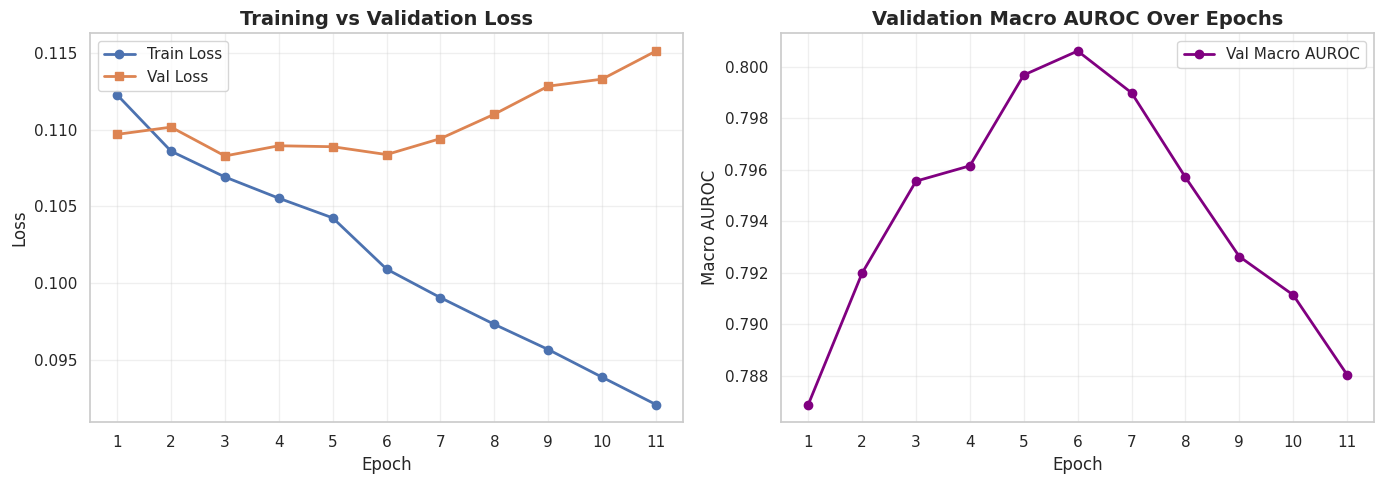

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(history):


    # Epoch indexing
    num_epochs = len(history["train_loss"])
    epochs = np.arange(1, num_epochs + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Loss curves
    ax1 = axes[0]
    ax1.plot(epochs, history["train_loss"], label="Train Loss", marker='o', linewidth=2, markersize=6)
    ax1.plot(epochs, history["val_loss"], label="Val Loss", marker='s', linewidth=2, markersize=6)

    ax1.set_title("Training vs Validation Loss", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)

    # Plot 2: Macro AUROC curve
    ax2 = axes[1]
    ax2.plot(epochs, history["val_macro_auroc"], label="Val Macro AUROC", color='purple',
             marker='o', linewidth=2, markersize=6)

    ax2.set_title("Validation Macro AUROC Over Epochs", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Macro AUROC", fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(epochs)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

In [ ]:
torch.save(model, (checkpoint_dir+"/final"))

#Model Testing

In [ ]:
# Load (in a new session/process)
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading best model")
model_best =CheXDFuseNet(num_classes=num_classes).to(device2)      # recreate the architecture
checkpoint = torch.load("/content/drive/MyDrive/checkpoints/NIH Pretrained weights on Chexpert/best_model_epoch_6.pth", map_location="cpu", weights_only=False)
history = checkpoint['history']
model_best.load_state_dict(checkpoint['model_state_dict'])
model_best.eval()                      # important for inference

Loading best model

Loading BiomedCLIP ViT Branch (Fixed with Projection)

Loading BiomedCLIP from HuggingFace...
BiomedCLIP loaded successfully!
Vision encoder extracted
    BiomedCLIP inferred dim: 512

Setting up dimension projection...
    Input dimension: 512
    Target dimension: 768
Projection layer created (512 → 768)

Configuration:
  Model: BiomedCLIP
  Input Dim: 512
  Output Dim: 768
  Projection: True
  Frozen: False
  Dropout: 0.1
  CLIP Model Type: <class 'open_clip.timm_model.TimmModel'>
  CLIP Model: TimmModel(
  (trunk): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bi

CheXDFuseNet(
  (cnn_branch): CNNBranch(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, tr

In [ ]:

print("Postive and negative samples in the test set")
print("="*70)
for label in chexpert_labels:
    positives = (test_df[label] == 1).sum()
    negatives = (test_df[label] == 0).sum()
    print(f"{label}: +{positives}, -{negatives}")

Postive and negative samples in the test set
Atelectasis: +75, -127
Cardiomegaly: +66, -136
Consolidation: +32, -170
Edema: +42, -160
Enlarged Cardiomediastinum: +105, -97
Lung Opacity: +117, -85
Lung Lesion: +1, -201
Pneumonia: +8, -194
Pneumothorax: +7, -195
Pleural Effusion: +64, -138
Pleural Other: +1, -201
Fracture: +0, -202
Support Devices: +99, -103
No Finding: +26, -176


In [ ]:

def plot_roc_curves(y_true, y_prob, class_names):
    n_classes = y_true.shape[1]
    plt.figure(figsize=(16, 12))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    # Plot micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_prob.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, color='black', lw=3, linestyle='--',
             label=f'Micro-average ROC curve (AUC = {roc_auc_micro:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves per Class and Micro-average')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)
    plt.show()


In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss, classification_report, roc_curve, auc
import matplotlib.pyplot as plt


def evaluate_test_set(model, test_loader, device, class_names, val_optimal_thresholds=None):
    model.eval()
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            targets = targets.to(device)
            model_output = model(images)
            logits = model_output[0]
            w_cnn, w_vit = model_output[1]
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())

    y_true = torch.cat(all_targets).numpy()
    y_prob = torch.sigmoid(torch.cat(all_logits)).numpy()

    # Define classes to exclude from the final report and metric calculation
    classes_to_exclude_from_report = ["Pleural Other", "Lung Lesion", "Fracture"]

    # Determine indices of classes to keep
    initial_class_names = list(class_names)
    keep_indices = [i for i, name in enumerate(initial_class_names) if name not in classes_to_exclude_from_report]

    if len(keep_indices) < len(initial_class_names):
        excluded_names = [name for i, name in enumerate(initial_class_names) if i not in keep_indices]
        print(f"Excluding classes from report: {excluded_names}")
    else:
        print("No specific classes were excluded from the report.")

    y_true = y_true[:, keep_indices]
    y_prob = y_prob[:, keep_indices]
    class_names = [initial_class_names[i] for i in keep_indices]

    # Use validation-set thresholds if provided
    if val_optimal_thresholds is not None:
        # Ensure thresholds are also filtered based on kept classes
        thresholds = val_optimal_thresholds[keep_indices]
        print("Using validation-set optimal thresholds, filtered for excluded classes.")
    else:
        thresholds = compute_optimal_thresholds(y_true, y_prob, step=0.01)
        print("Computed optimal thresholds on test set (after excluding specified classes).")
    print(np.round(thresholds, 3))

    y_pred = apply_thresholds(y_prob, thresholds)

    macro_auc = np.nanmean([
        roc_auc_score(y_true[:, i], y_prob[:, i]) if np.sum(y_true[:, i]) > 0 else np.nan
        for i in range(y_true.shape[1])
    ])

    micro_f1 = f1_score(y_true.flatten(), y_pred.flatten(), zero_division=0)
    ham_loss = hamming_loss(y_true, y_pred)

    print("\nTest Set Metrics (after excluding specified classes):")
    print(f"Macro AUROC: {macro_auc:.4f}")
    print(f"Micro F1-score: {micro_f1:.4f}")
    print(f"Hamming Loss: {ham_loss:.4f}\n")

    print("Detailed Classification Report (after excluding specified classes):")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    plot_roc_curves(y_true, y_prob, class_names)

    return {
        "macro_auc": macro_auc,
        "micro_f1": micro_f1,
        "hamming_loss": ham_loss,
        "optimal_thresholds": thresholds
    }

Excluding classes from report: ['Lung Lesion', 'Pleural Other', 'Fracture']
Using validation-set optimal thresholds, filtered for excluded classes.
[0.5  0.56 0.44 0.56 0.43 0.55 0.43 0.54 0.56 0.61 0.56]

Test Set Metrics (after excluding specified classes):
Macro AUROC: 0.8208
Micro F1-score: 0.6365
Hamming Loss: 0.1881

Detailed Classification Report (after excluding specified classes):
                            precision    recall  f1-score   support

               Atelectasis       0.69      0.59      0.63        75
              Cardiomegaly       1.00      0.26      0.41        66
             Consolidation       0.45      0.28      0.35        32
                     Edema       0.65      0.86      0.74        42
Enlarged Cardiomediastinum       0.86      0.06      0.11       105
              Lung Opacity       0.82      0.88      0.85       117
                 Pneumonia       0.25      0.25      0.25         8
              Pneumothorax       0.25      0.57      0.35     

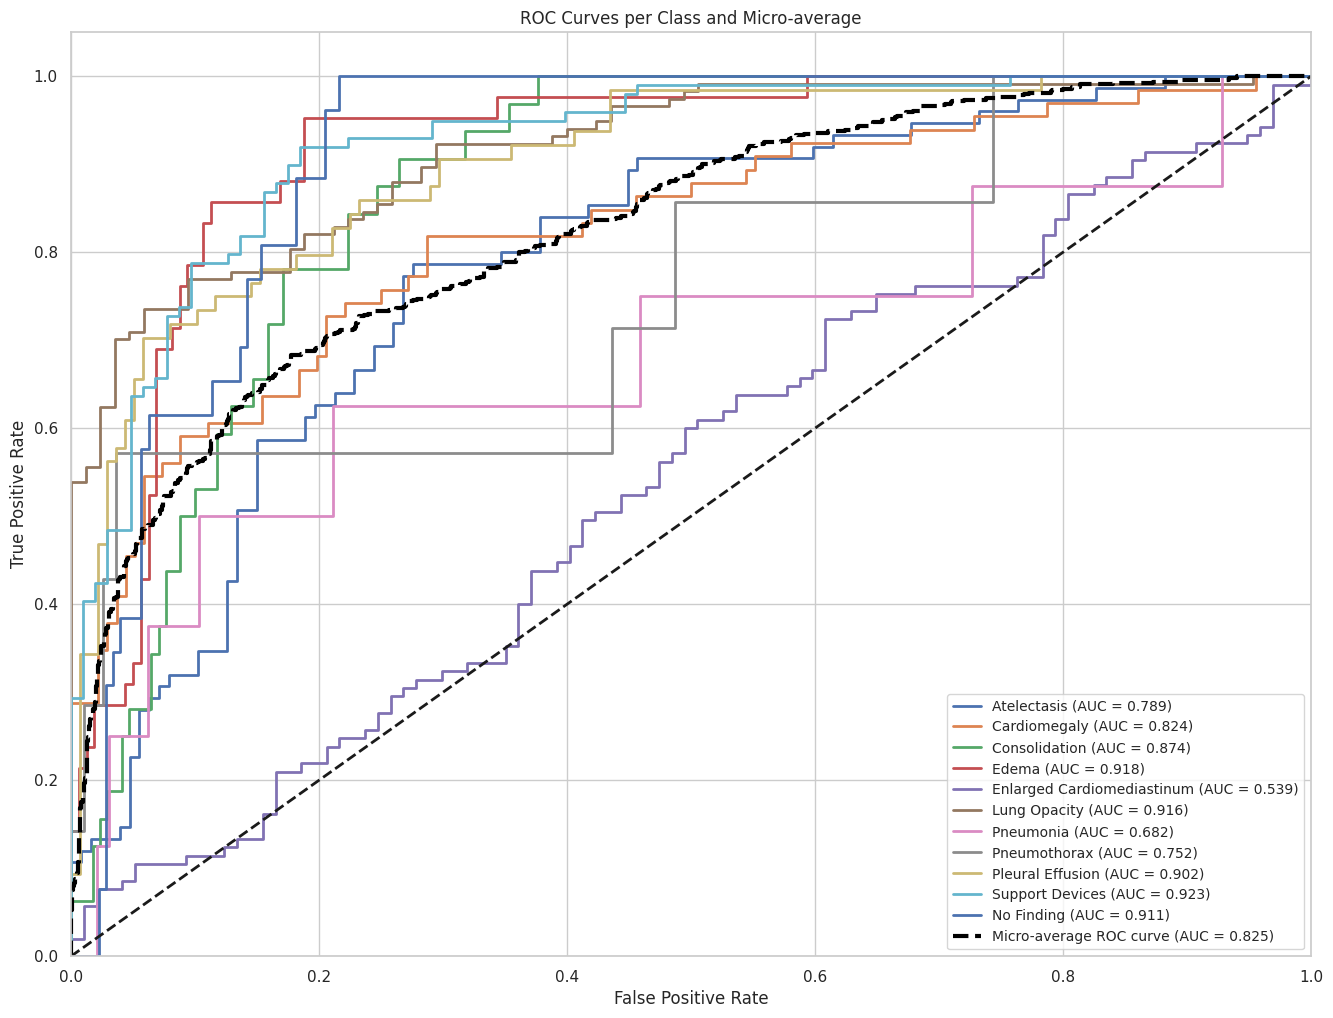

In [ ]:
threshold = history["optimal_thresholds"][5]

results = evaluate_test_set(model_best, test_loader, device, chexpert_labels,np.array(threshold))